<a href="https://colab.research.google.com/github/Chafingdish/ML-workshop/blob/main/Tutorials/Tutorial1_PyTorch_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Tutorial:

Adapted from the PyTorch Tutorial by Jamie Meindl:
https://www.youtube.com/watch?v=o5gPABcGZwc&list=PLUl4u3cNGP63URZnh5iqBzDTDYPUTQT-8&index=24

Relavant resources:
1) https://github.com/davidbau/how-to-read-pytorch
2) https://pytorch.org/tutorials/beginner/basics/intro.html


In [1]:
import math
import numpy as np
import torch
from matplotlib import pyplot as plt

Topic 1: PyTorch Tensors
===============

The first big trick for doing math fast on a modern computer is to do giant array operations all at once.

To faciliate this, pytorch provides a [`torch.Tensor`](https://pytorch.org/docs/stable/tensors.html) class that is a lookalike to the older python numerical library [`numpy.ndarray`](https://numpy.org/doc/1.18/reference/arrays.ndarray.html).  Just like a numpy `ndarray`, the pytorch `Tensor` stores a d-dimensional array of numbers, where d can be zero or more, and where the contained numbers can be any of the usual selection of float or integer types.  Pytorch is designed to feel just like numpy: almost all the numpy operations are also available on torch tensors. But if something is missing, torch tensors can be directly converted to and from numpy using `x.numpy()` and `torch.from_numpy(a)`. So what is different and why did the pytorch authors bother to reimplement this whole library?

**There are two things that pytorch Tensors have that numpy arrays lack:**

 1. pytorch Tensors can live on either **GPU or CPU** (numpy is cpu-only).
 2. pytorch can automatically track tensor computations to enable **automatic differentiation**.


Initializing a Tensor
=====================

Tensors can be initialized in various ways. Take a look at the following
examples:

**Directly from data**

Tensors can be created directly from data. The data type is
automatically inferred.


In [2]:
data = [[1, 2],[3, 4]]
x_data = torch.tensor(data)
print(x_data)

tensor([[1, 2],
        [3, 4]])


**From a NumPy array**

Tensors can be created from NumPy arrays and vice versa - see [Bridge with NumPy](https://pytorch.org/tutorials/beginner/blitz/tensor_tutorial.html#bridge-to-np-label).


In [3]:
np_array = np.array(data)
x_np = torch.from_numpy(np_array)
print(x_np)

tensor([[1, 2],
        [3, 4]])


**From another tensor:**

The new tensor retains the properties (shape, datatype) of the argument
tensor, unless explicitly overridden.


In [4]:
x_ones = torch.ones_like(x_data) # retains the properties of x_data
print(f"Ones Tensor: \n {x_ones} \n")

x_rand = torch.rand_like(x_data, dtype=torch.float) # overrides the datatype of x_data
print(f"Random Tensor: \n {x_rand} \n")

Ones Tensor: 
 tensor([[1, 1],
        [1, 1]]) 

Random Tensor: 
 tensor([[0.6308, 0.1364],
        [0.7657, 0.2934]]) 



**With random or constant values:**

`shape` is a tuple of tensor dimensions. In the functions below, it
determines the dimensionality of the output tensor.


In [5]:
shape = (2,3)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)

print(f"Random Tensor: \n {rand_tensor} \n")
print(f"Ones Tensor: \n {ones_tensor} \n")
print(f"Zeros Tensor: \n {zeros_tensor}")

Random Tensor: 
 tensor([[0.0840, 0.2218, 0.3964],
        [0.1760, 0.0483, 0.5503]]) 

Ones Tensor: 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

Zeros Tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]])


------------------------------------------------------------------------


Attributes of a Tensor
======================

Tensor attributes describe their shape, datatype, and the device on
which they are stored.


In [6]:
tensor = torch.rand(3,4)

print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")

Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


Basic operations in the Tensor API
----------------------------------

Pytorch is not very different from numpy, although the pytorch API has more convenience methods such as `x.clamp(0).pow(2)` (supporting a chained method style, as is popular in Javascript libraries, so you don't need to say the verbose `numpy.clip(numpy.pow(x, 2), 0)`). So code is often shorter in pytorch.  A brief overview:

**Elementwise operations.** Most tensor operations are simple (embarassingly parallelizable) elementwise operations, where the same math is done on every element of the array.  `x+y`, `x*y`, `x.abs()`, `x.pow(3)`, etc.  Unlike Matlab, `*` is for element-wise multiplication, not matrix-multiplication.

**Copy semantics by default.** Almost all operations, including things like `x.sort()`, return a new copy of the tensor without overwriting the input tensors.  The exceptions are functions that end in an underscore such as `x.mul_(2)` which doubles the contents of x in-place.

**Common reduction operations.**  There are some common operations such as `max`, `min`, `mean`, `sum` that reduce the array by one or more dimension. In pytorch, you can specify which dimension you want to reduce by passing the argument `dim=n`.

**Why does min return two things?** Note that `[data, indexes] = x.sort(dim=0)` and `[vals, indexes] = x.min(dim=0)` return the pair of both the answer and the index values, so you do not need to separately recompute `argsort` or `argmin` when you need to know where the min came from.

**What about linear algebra?** It's there.  `torch.mm(a,b)` is matrix multiplication, `torch.inverse(a)` inverts, `torch.eig(a)` gets eigenvalues, etc.

The other thing to know is that pytorch tends to be very fast, often much faster than numpy even on CPU, because its implementation is aggressively parallelized behind-the-scenes.  Pytorch is willing to use multiple threads in situations where numpy just uses one.

See the [reference for Tensor methods](https://pytorch.org/docs/stable/tensors.html#torch.Tensor) for what comes built-in.  A simple demo of some vectors:



In [7]:
# Make a vector of 101 equally spaced numbers from 0 to 5.
x = torch.linspace(0, 5, 101)

# Print the first five things in x.
print(x[:5])

tensor([0.0000, 0.0500, 0.1000, 0.1500, 0.2000])


### Exercise

Print the last five things in x.

In [8]:
# Todo: Print the last five things in x (instead of the first five)

print(x[-5:])

tensor([4.8000, 4.8500, 4.9000, 4.9500, 5.0000])


The shape of x is torch.Size([101])
The shape of y1=x.sin() is torch.Size([101])
The shape of y2=x ** x.cos() is torch.Size([101])
The shape of y3=y2 - y1 is torch.Size([101])
The shape of y4=y3.min() is torch.Size([]), a zero-d scalar


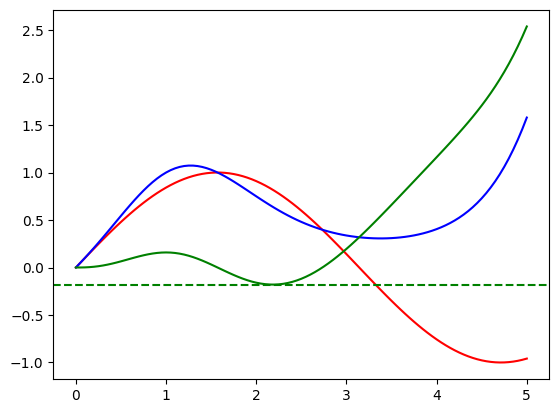

In [9]:
# Do some vector computations.
y1, y2 = x.sin(), x ** x.cos()
y3 = y2 - y1
y4 = y3.min()

# Print and plot some answers.
print(f'The shape of x is {x.shape}')
print(f'The shape of y1=x.sin() is {y1.shape}')
print(f'The shape of y2=x ** x.cos() is {y2.shape}')
print(f'The shape of y3=y2 - y1 is {y3.shape}')
print(f'The shape of y4=y3.min() is {y4.shape}, a zero-d scalar')

plt.plot(x, y1, 'red', x, y2, 'blue', x, y3, 'green')
plt.axhline(y4, color='green', linestyle='--')
plt.show()

### Exercise

Plot y3 clamped between 0.0 and 1.0.

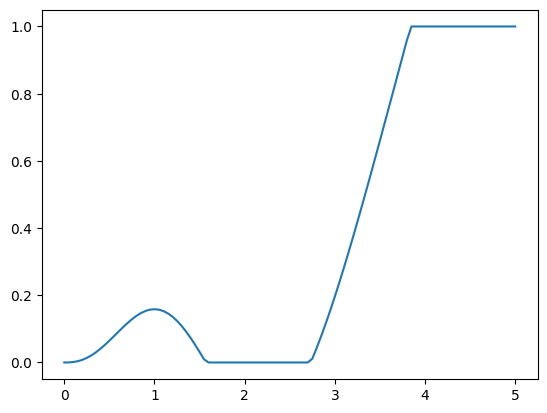

In [10]:
# Todo: Plot y3 clamped between 0.0 and 1.0.

y4 = y3.clamp(0,1)

plt.plot(x,y4)
plt.show()


PyTorch Tensor dimension-ordering conventions
---------------------------------------------

**Multidimensional data convention.** As soon as you have more than one dimension, you need to decide how to order the axes.  To reduce confusion, most data processing follows the same global convention. In particular, much image-related data in pytorch is four dimensional, and the dimensions are ordered like this: `data[batch_index, channel_index, y_position, x_position]`, that is:

* Dimension 0 is used to index separate images within a batch.
* Dimension 1 indexes channels within an image representation (e.g., 0,1,2 = R,G,B, or more dims for more channels).
* Dimension 2 (if present) indexes the row position (y-value, starting from the top)
* Dimension 3 (if present) indexes the column position (x-value, starting from the left)

There a way to remember this ordering: adjacent entries that vary only in the last dimensions are stored physically closer in RAM; since they are often combined with each other, this could help with locality, whereas the first (batch) dimension usually just groups separate independent data points which are not combined much, so they do not need to be physically close.

Stream-oriented data without grid geometry will drop the last dimensions, and 3d grid data will be 5-dimensional, adding a depth z before y.  This same 4d-axis ordering convention is also seen in caffe and tensorflow.

Separate tensors can be put together into a single batch tensor using `torch.cat([a, b, c])` or `torch.stack([a, b, c])`.  (The difference: `cat` doesn't add any new dimensions but just concatenates along the existing 0th dimension.  `stack` adds a new 0th dimension for the batch.)

**Multidimensional linear operation convention.** When storing matrix weights or convolution weights, linear algebra conventions are followed
* Dimension 0 (number of rows) matches the output channel dimension
* Dimension 1 (number of columns) matches the input channel dimension
* Dimension 2 (if present) is the convolutional kernel y-dimension
* Dimension 3 (if present) is the convolutional kernel x-dimension

Since this convention assumes channels are arranged in different rows whereas the data convention puts different batch items in different rows, some axis transposition is often needed before applying linear algebra to the data.

**Permute and view reshape an array without moving memory.** The `permute` and `view` methods are useful for rearranging, flattening, and unflatteneing axes. `x.permute(1,0,2,3).view(x.shape[1], -1)`.  They just alter the view of the block of numbers in memory without moving any of the numbers around, so they are fast.

**Reshaping sometimes needs copying.** Some sequences of axis permutations and flattenings cannot be done without copying the data into the new order in memory; the `x.contiguous()` method copies the data into the natural order given by the current view; also `x.reshape()` is similar to `view` but will make a copy if necessary so you do not need to think about it.  See [the Tensor.view method documentation](https://pytorch.org/docs/master/tensors.html#torch.Tensor.view).


### Exercise

Use `torch.randn` to create a four-dimensional tensor `x` of size (2,3,4,5), which could store two 5x4 RGB images.

Then print three things:
 * print `x`.
 * Use `x.permute` to switch the horizontal and vertical (last two) dimensions.
 * Use `x.view` to see each image as a flat vector of 60 numbers.

In [11]:
# TODO make x of size (2,3,4,5), and print three rearrangements of x
x = torch.rand((2,3,4,5))
print(x.shape)

# Permute dimensions
print(x.permute((0,1,3,2)).shape)

# Reshape
print(x.view(x.shape[0],-1).shape)

torch.Size([2, 3, 4, 5])
torch.Size([2, 3, 5, 4])
torch.Size([2, 60])


**Standard numpy-like indexing and slicing:**


In [12]:
tensor = torch.ones(4, 4)
print(f"First row: {tensor[0]}")
print(f"First column: {tensor[:, 0]}")
print(f"Last column: {tensor[:, -1]}")
tensor[:,1] = 0
print(tensor)

First row: tensor([1., 1., 1., 1.])
First column: tensor([1., 1., 1., 1.])
Last column: tensor([1., 1., 1., 1.])
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


**Joining tensors** You can use `torch.cat` to concatenate a sequence of
tensors along a given dimension. See also
[torch.stack](https://pytorch.org/docs/stable/generated/torch.stack.html),
another tensor joining operator that is subtly different from
`torch.cat`.


In [13]:
t1 = torch.cat([tensor, tensor, tensor], dim=0) # Concatanates along dimension
print(tensor)
print(tensor.shape)
print(t1)
print(t1.shape)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])
torch.Size([4, 4])
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])
torch.Size([12, 4])


In [14]:
t2 = torch.stack([tensor, tensor, tensor], dim=1) # Creates new dimension
print(tensor)
print(tensor.shape)
print(t2)
print(t2.shape)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])
torch.Size([4, 4])
tensor([[[1., 0., 1., 1.],
         [1., 0., 1., 1.],
         [1., 0., 1., 1.]],

        [[1., 0., 1., 1.],
         [1., 0., 1., 1.],
         [1., 0., 1., 1.]],

        [[1., 0., 1., 1.],
         [1., 0., 1., 1.],
         [1., 0., 1., 1.]],

        [[1., 0., 1., 1.],
         [1., 0., 1., 1.],
         [1., 0., 1., 1.]]])
torch.Size([4, 3, 4])


**Empty Dimensions**

In [15]:
t3 = tensor.unsqueeze(0)
print(tensor.shape)
print(t3.shape)
print(t3)
t4 = t3.squeeze(0)
print(tensor.shape)
print(t4.shape)
print(t4)


torch.Size([4, 4])
torch.Size([1, 4, 4])
tensor([[[1., 0., 1., 1.],
         [1., 0., 1., 1.],
         [1., 0., 1., 1.],
         [1., 0., 1., 1.]]])
torch.Size([4, 4])
torch.Size([4, 4])
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


**Arithmetic operations**


In [17]:
# This computes the matrix multiplication between two tensors. y1, y2, y3 will have the same value
# ``tensor.T`` returns the transpose of a tensor
tensor = torch.Tensor([[1,2,5],[3,4,6]])
print(tensor.shape)

y1 = tensor @ tensor.T
y2 = tensor.matmul(tensor.T)
y3 = torch.rand_like(y1)
torch.matmul(tensor, tensor.T, out=y3)
print(y1, y1.shape)
print(y2, y2.shape)
print(y3, y3.shape)


torch.Size([2, 3])
tensor([[30., 41.],
        [41., 61.]]) torch.Size([2, 2])
tensor([[30., 41.],
        [41., 61.]]) torch.Size([2, 2])
tensor([[30., 41.],
        [41., 61.]]) torch.Size([2, 2])


In [18]:
# This computes the element-wise product. z1, z2, z3 will have the same value
z1 = tensor * tensor
z2 = tensor.mul(tensor)

z3 = torch.rand_like(tensor)
torch.mul(tensor, tensor, out=z3)
print(z1, z1.shape)
print(z2)
print(z3)

tensor([[ 1.,  4., 25.],
        [ 9., 16., 36.]]) torch.Size([2, 3])
tensor([[ 1.,  4., 25.],
        [ 9., 16., 36.]])
tensor([[ 1.,  4., 25.],
        [ 9., 16., 36.]])


**Single-element tensors** If you have a one-element tensor, for example
by aggregating all values of a tensor into one value, you can convert it
to a Python numerical value using `item()`:


In [19]:
agg = tensor.sum()
print(agg, type(agg), agg.dtype)
print(agg.shape)
agg_item = agg.item()
print(agg_item, type(agg_item))

tensor(21.) <class 'torch.Tensor'> torch.float32
torch.Size([])
21.0 <class 'float'>


Topic 2: Pytorch Autograd
================

If you flag a torch Tensor with the attribute `x.requires_grad=True`, then pytorch will automatically keep track the computational history of all tensors that are derived from `x`.  This allows pytorch to figure out derivatives of any scalar result with regard to changes in the components of x.

The function `torch.autograd.grad(output_scalar, [list of input_tensors])` computes `d(output_scalar)/d(input_tensor)` for each input tensor component in the list.  For it to work, the input tensors and output must be part of the same `requires_grad=True` compuation.

In the example here, `x` is explicitly marked `requires_grad=True`, so `y.sum()`, which is derived from `x`, automatically comes along with the computation history, and can be differentiated.

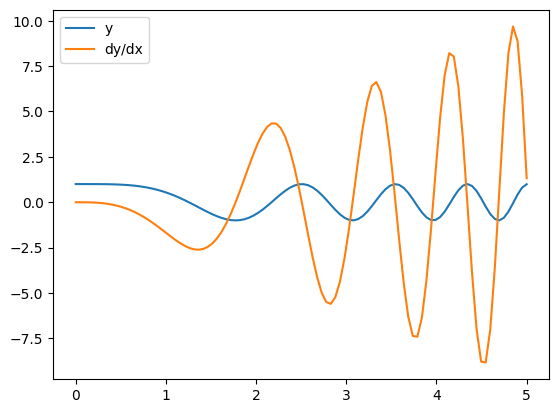

In [20]:
x = torch.linspace(0, 5, 100,
          requires_grad=True)
y = (x**2).cos()
s = y.sum()
[dydx] = torch.autograd.grad(s, [x])

plt.plot(x.detach(), y.detach(), label='y')
plt.plot(x.detach(), dydx, label='dy/dx')
plt.legend()
plt.show()

(Note that in the example above, because the components of the vector space are independent of each other, we happen to have `dy[j] / dx[i] == 0` when `j != i`, so that `d(y.sum())/dx[i] = dy[i]/dx[i]`.  That means computing a single gradient vector of the sum `s` is equiavlent to computing elementwise derivatives `dy/dx`.)

**Detaching tensors from the computation history.** Every tensor that depends on `x` will be `requires_grad=True` and connected to the complete computation history. But if you were to convert a tensor to a regular python number, pytorch would not be able to see the calculations and would not be able to compute gradients on it.

To avoid programming mistakes where some computation invisibly goes through a non-pytorch number that cannot be tracked, pytorch disables requires-grad tensors from being converted to untrackable numbers.  You need to explicitly call `x.detach()` or `y.detach()` first, to explicitly say that you want an untracked reference, before plotting the data or using it as non-pytorch numbers.

### Exercise

Plot the polynomial y=x<sup>3</sup>-6x<sup>2</sup>+8x and its derivative, instead of cos(x<sup>2</sup>).

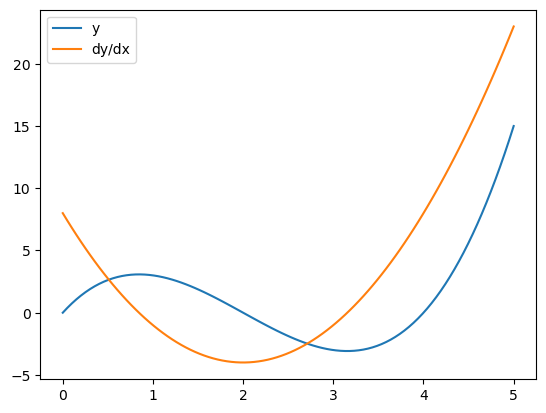

In [ ]:
# TODO: set y to the given polynomial of x
x = torch.linspace(0, 5, 100,
          requires_grad=True)
y = x**3 - 6*x**2 + 8*x

# TODO: use autograd to compute the derivative
s = y.sum()
[dydx] = torch.autograd.grad(s, [x])

# TODO: plot the results.
plt.plot(x.detach(), y.detach(), label='y')
plt.plot(x.detach(), dydx, label='dy/dx')
plt.legend()
plt.show()

Backprop and In-place gradients
-------------------------------

In a typical neural network we will not just be getting gradients with regard to one input like `x` above, but with regard to a list of dozens or hundreds of tensor parameters that have all been marked with `requires_grad=True`.  It can be inconvenient to keep track of which gradient outputs go with which original tensor input.  But since the gradients have exactly the same shape as the inputs, it is natural to store computed gradients in-place on the tensors themselves.

**Using `backward()` to add `.grad` attributes.** To simplify this common operation, pytorch provides the `y.backward()` method, which computes the gradients of y with respect to every tracked dependency, and stores the results in the field `x.grad` for every original input vector `x` that was marked as `requires_grad=True`.

tensor([-0.0000e+00, -2.5765e-04, -2.0612e-03, -6.9560e-03, -1.6485e-02,
        -3.2185e-02, -5.5575e-02, -8.8145e-02, -1.3133e-01, -1.8650e-01,
        -2.5487e-01, -3.3752e-01, -4.3528e-01, -5.4869e-01, -6.7791e-01,
        -8.2262e-01, -9.8193e-01, -1.1543e+00, -1.3373e+00, -1.5279e+00,
        -1.7218e+00, -1.9138e+00, -2.0978e+00, -2.2665e+00, -2.4118e+00,
        -2.5246e+00, -2.5954e+00, -2.6144e+00, -2.5720e+00, -2.4592e+00,
        -2.2684e+00, -1.9940e+00, -1.6330e+00, -1.1861e+00, -6.5843e-01,
        -5.9786e-02,  5.9438e-01,  1.2829e+00,  1.9791e+00,  2.6508e+00,
         3.2620e+00,  3.7737e+00,  4.1467e+00,  4.3434e+00,  4.3315e+00,
         4.0872e+00,  3.5983e+00,  2.8676e+00,  1.9159e+00,  7.8273e-01,
        -4.7262e-01, -1.7729e+00, -3.0265e+00, -4.1327e+00, -4.9894e+00,
        -5.5028e+00, -5.5970e+00, -5.2252e+00, -4.3782e+00, -3.0925e+00,
        -1.4526e+00,  4.1007e-01,  2.3249e+00,  4.0956e+00,  5.5192e+00,
         6.4094e+00,  6.6222e+00,  6.0798e+00,  4.7

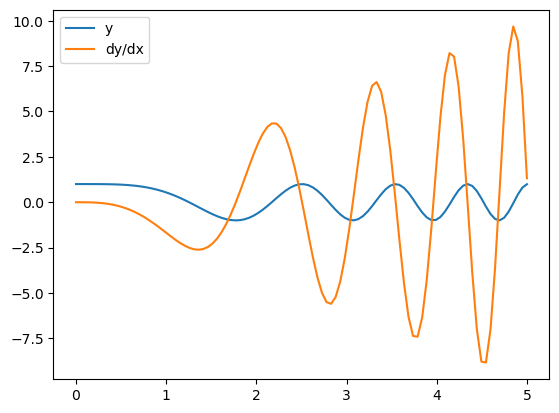

In [ ]:
x = torch.linspace(0, 5, 100, requires_grad=True)
y = (x**2).cos()
y.sum().backward()   # populates the grad attribute below.
print(x.grad)

plt.plot(x.detach(), y.detach(), label='y')
plt.plot(x.detach(), x.grad, label='dy/dx')
plt.legend()
plt.show()